# Titanic Survival Prediction — ANN Model
Complete pipeline: Load → EDA → Preprocess → SMOTE → Build ANN → Evaluate

## STEP 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


## STEP 2 — Load Dataset

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## STEP 3 — EDA (Exploratory Data Analysis)

In [ ]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Survived value counts:
Survived
0    549
1    342
Name: count, dtype: int64


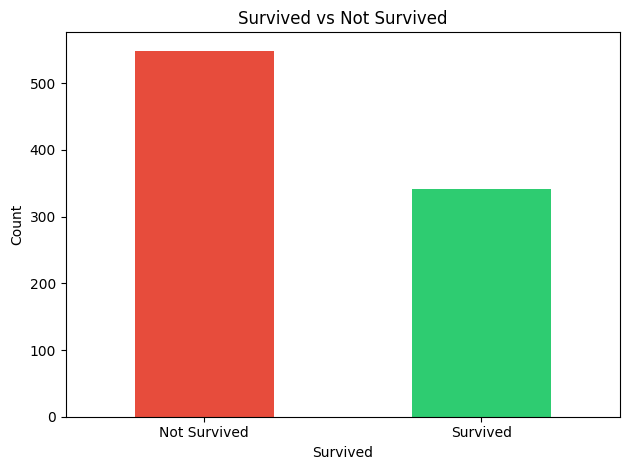

In [ ]:
print('Survived value counts:')
print(df['Survived'].value_counts())

df['Survived'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Survived vs Not Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.xticks([0,1], ['Not Survived','Survived'], rotation=0)
plt.tight_layout()
plt.show()

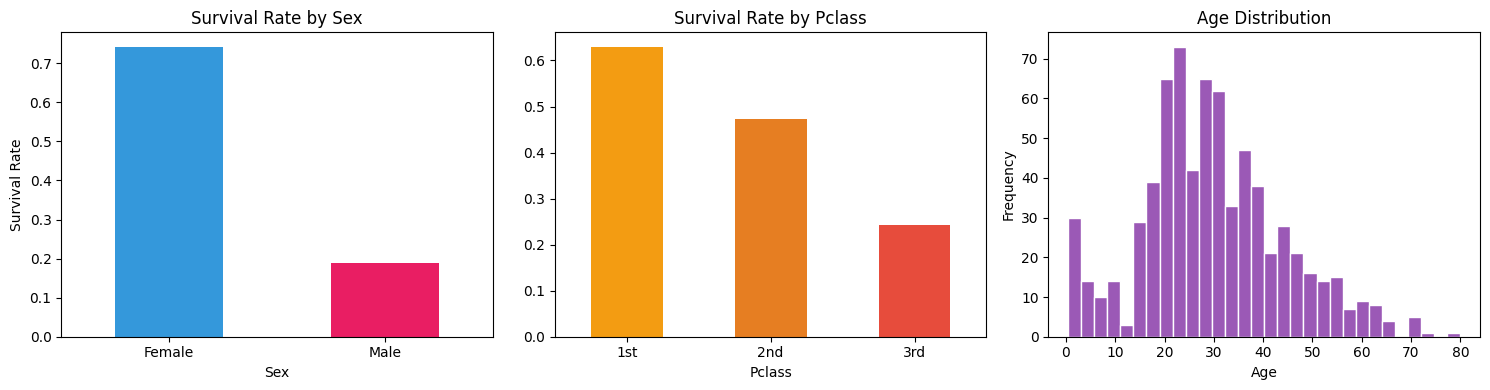

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['#3498db','#e91e63'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(['Female','Male'], rotation=0)

# Survival by Pclass
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['#f39c12','#e67e22','#e74c3c'])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_xticklabels(['1st','2nd','3rd'], rotation=0)

# Age distribution
df['Age'].plot(kind='hist', bins=30, ax=axes[2], color='#9b59b6', edgecolor='white')
axes[2].set_title('Age Distribution')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

## STEP 4 — Data Preprocessing

In [ ]:
# Drop irrelevant columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print('Missing values after fill:')
print(df.isnull().sum())

Missing values after fill:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [ ]:
# Encode categorical columns
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])  # C=0, Q=1, S=2

print('Encoded data sample:')
df.head()

Encoded data sample:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


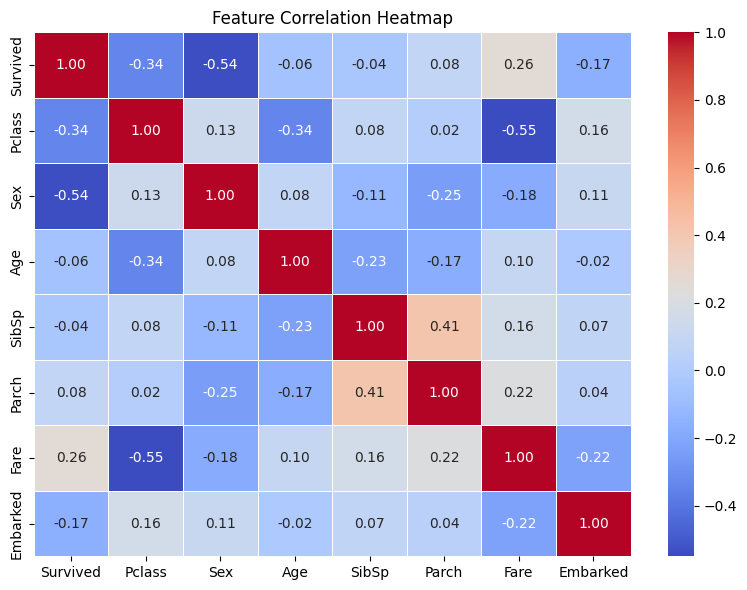

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## STEP 5 — Train-Test Split

In [ ]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train distribution:\n', y_train.value_counts())

X_train shape: (712, 7)
X_test shape : (179, 7)
y_train distribution:
 Survived
0    439
1    273
Name: count, dtype: int64


## STEP 6 — Handle Class Imbalance (SMOTE)

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
Survived
1    439
0    439
Name: count, dtype: int64


## STEP 7 — Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done!')
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape :', X_test_scaled.shape)

Scaling done!
X_train_scaled shape: (878, 7)
X_test_scaled shape : (179, 7)


## STEP 8 — Build ANN Model

In [ ]:
tf.random.set_seed(42)

model = Sequential([
    # Hidden Layer 1
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden Layer 3
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 384 (1.50 KB)

## STEP 9 — Train the Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_sm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6667 - loss: 0.6588 - val_accuracy: 0.8807 - val_loss: 0.6186
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7821 - loss: 0.5206 - val_accuracy: 0.8807 - val_loss: 0.5983
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7806 - loss: 0.4936 - val_accuracy: 0.8807 - val_loss: 0.5697
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7963 - loss: 0.4775 - val_accuracy: 0.7841 - val_loss: 0.5535
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8020 - loss: 0.4487 - val_accuracy: 0.7841 - val_loss: 0.5378
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8048 - loss: 0.4564 - val_accuracy: 0.7841 - val_loss: 0.5239
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7991 - loss: 0.4488 - val_accuracy: 0.8636 - val_loss: 0.5032
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8205 - loss: 0.4276 - val_accuracy: 0.8693 - 

## STEP 10 — Evaluate on Test Set

In [ ]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print('Test Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('ROC-AUC Score :', round(roc_auc_score(y_test, y_pred_prob), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Survived','Survived']))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Test Accuracy : 0.8101
ROC-AUC Score : 0.8328

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.81      0.91      0.85       110
    Survived       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



## STEP 11 — Confusion Matrix

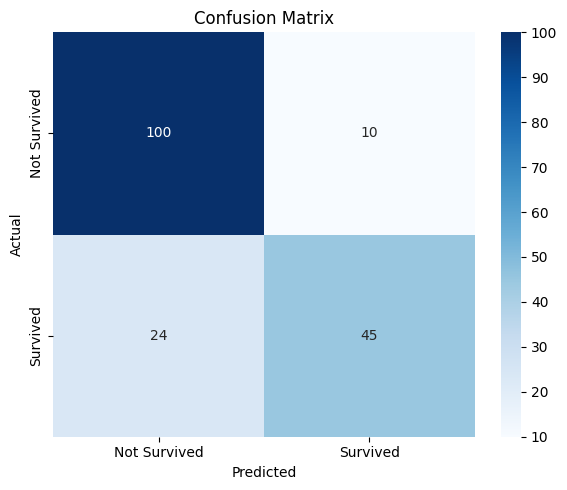

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## STEP 12 — Training History (Loss & Accuracy)

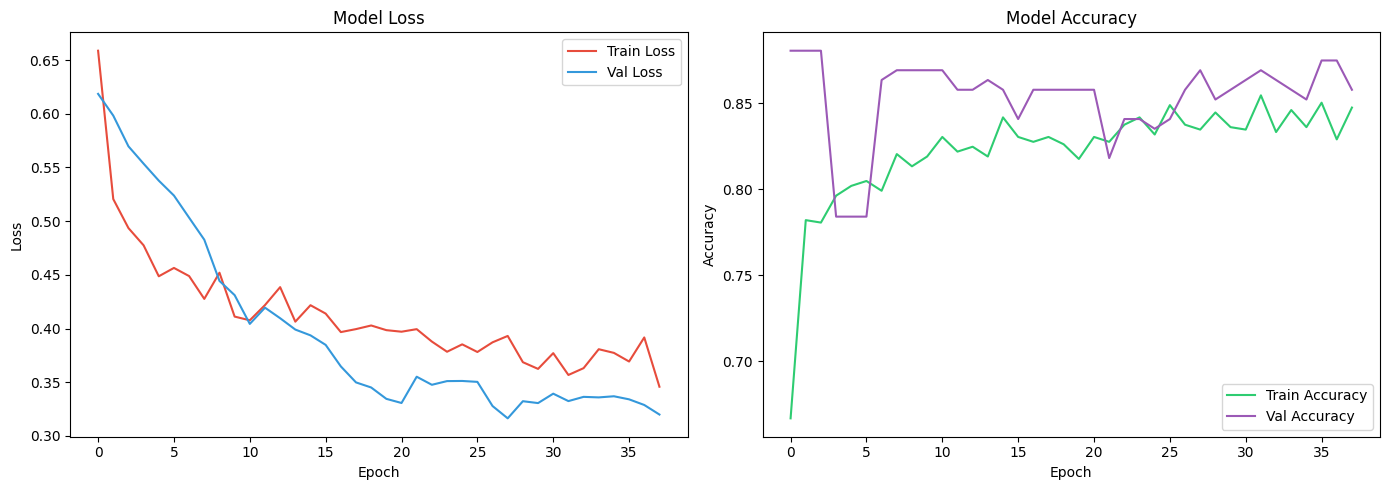

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#3498db')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#9b59b6')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## STEP 13 — ROC Curve

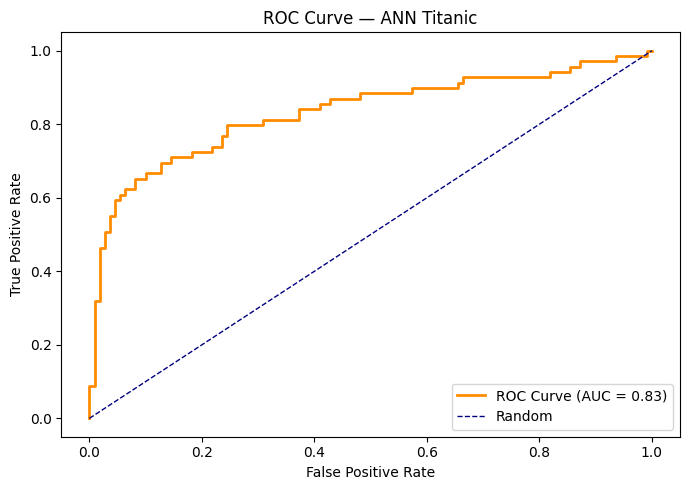

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ANN Titanic')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()